In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

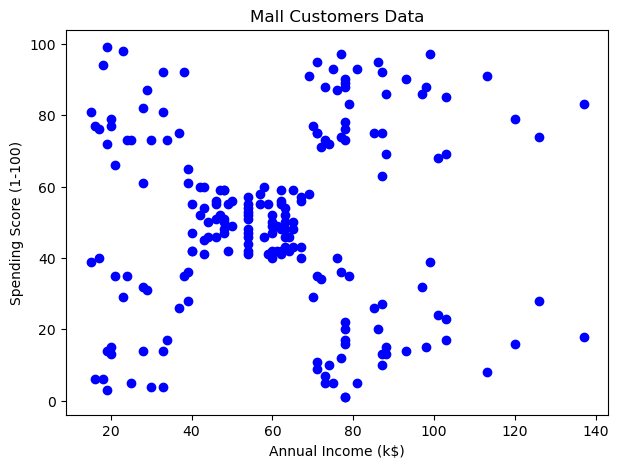

In [ ]:

from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r"C:\Users\new\Desktop\Mall_Customers.csv")

# Select required columns
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Plot graph
plt.figure(figsize=(7,5))
plt.scatter(
    x['Annual Income (k$)'],
    x['Spending Score (1-100)'],
    color='blue'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Mall Customers Data')
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

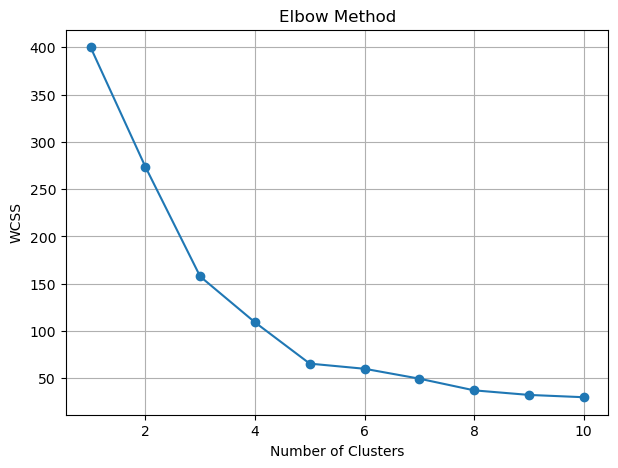

Optimal number of clusters: 5


In [ ]:

from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv(r"C:\Users\new\Desktop\Mall_Customers.csv")

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot graph
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()

# Optimal clusters
optimal_k = 5
print("Optimal number of clusters:", optimal_k)


In [11]:
 from sklearn.cluster import KMeans

 
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)

 
clusters = final_kmeans.fit_predict(X_scaled)

 
df['Cluster'] = clusters

 
print(df.head(10))

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


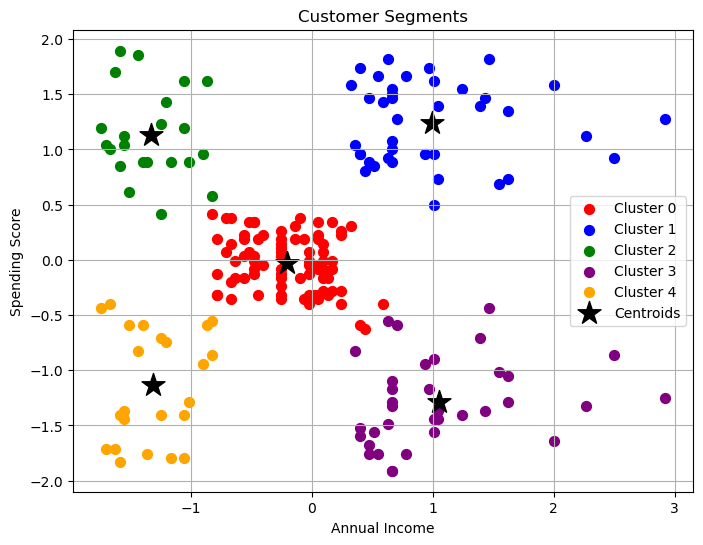

In [13]:
plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(optimal_k):

    plt.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        s=50,
        c=colors[i],
        label=f'Cluster {i}'
    )

# Centroids
centroids = final_kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='black',
    marker='*',
    label='Centroids'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend()
plt.grid(True)

plt.show()
